# Library

In [522]:
# pip install factor_analyzer

In [523]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.decomposition import FactorAnalysis
import pingouin as pg
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# Load Data (Internet Required)

In [524]:
df = pd.read_csv("https://docs.google.com/spreadsheets/d/1Dmy11XxB85wDM37S5MTCdGrlQ4zmzmTHGIcwUIj0eyU/export?format=csv")

In [525]:
# df.head()

# Rename Columns

In [526]:
df = df.rename(columns={'Kelas \n(Kelas LAB / Survey Sampling and Methodology)' : 'Kelas'})

In [527]:
new_columns_var_y = {
    old: f"Y{i+1}"
    for i, old in enumerate(df.columns[3:23])
}

In [528]:
df = df.rename(columns=new_columns_var_y)

In [529]:
df.iloc[:, 0:5].head()

,Timestamp,Kelas,Gender,Y1,Y2
0,5/13/2026 17:29:21,LC09,Pria,2,5
1,5/13/2026 18:16:32,LA09,Wanita,2,2
2,5/13/2026 19:23:32,LB09,Pria,3,2
3,5/13/2026 19:31:11,LB09,Pria,2,3
4,5/13/2026 21:07:03,LB09,Wanita,1,1


In [530]:
df.iloc[:, 20:25].head()

,Y18,Y19,Y20,"Selama periode Mid Exam (Semester 4), saya yakin mampu menyelesaikan tugas atau soal yang sulit jika saya berusaha dengan sungguh-sungguh.","Selama periode Mid Exam (Semester 4), ketika menghadapi hambatan dari orang lain, saya mampu menemukan jalan tengah dan cara untuk mencapai tujuan akademik saya\n(misal: keluarga, teman, atau orang lainnya)"
0,4,3,5,3,3
1,4,5,5,3,2
2,3,3,2,4,3
3,3,4,3,3,3
4,4,4,1,3,3


In [531]:
new_columns_var_x = {
    old: f"X{i+1}"
    for i, old in enumerate(df.columns[23:33])
}

In [532]:
df = df.rename(columns=new_columns_var_x)

In [533]:
df.iloc[:, 20:25].head()

,Y18,Y19,Y20,X1,X2
0,4,3,5,3,3
1,4,5,5,3,2
2,3,3,2,4,3
3,3,4,3,3,3
4,4,4,1,3,3


In [534]:
df.iloc[:, 28:33].head()

,X6,X7,X8,X9,X10
0,3,2,3,2,2
1,3,2,2,2,2
2,4,3,3,3,2
3,4,3,4,3,4
4,3,3,3,3,3


# Split DataFrame
Variable Y for Clustering = Target<br>
VAriable X + 'Gender' + 'Kelas' + 'label' for Classification

In [535]:
var_y = df.iloc[:, 3:23]

In [536]:
var_y.head()

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
0,2,5,5,5,4,5,5,5,5,3,3,2,5,4,4,2,5,4,3,5
1,2,2,4,3,4,2,4,4,4,3,4,4,4,2,2,2,5,4,5,5
2,3,2,5,4,2,3,4,5,3,3,4,4,4,3,3,2,3,3,3,2
3,2,3,4,4,3,3,4,2,2,3,5,4,3,4,4,2,3,3,4,3
4,1,1,2,3,3,3,4,3,3,4,2,2,2,3,3,2,1,4,4,1


In [537]:
var_x = df.iloc[:, 23:33]

In [538]:
var_x.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,3,3,2,2,3,3,2,3,2,2
1,3,2,2,2,2,3,2,2,2,2
2,4,3,3,2,2,4,3,3,3,2
3,3,3,3,2,3,4,3,4,3,4
4,3,3,2,2,3,3,3,3,3,3


# Variable Setup

## Variable Y

In [539]:
var_y.head()

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
0,2,5,5,5,4,5,5,5,5,3,3,2,5,4,4,2,5,4,3,5
1,2,2,4,3,4,2,4,4,4,3,4,4,4,2,2,2,5,4,5,5
2,3,2,5,4,2,3,4,5,3,3,4,4,4,3,3,2,3,3,3,2
3,2,3,4,4,3,3,4,2,2,3,5,4,3,4,4,2,3,3,4,3
4,1,1,2,3,3,3,4,3,3,4,2,2,2,3,3,2,1,4,4,1


Sub Skala Dari Indikator Variabel Y (ASI | Academic Stress Inventory)
- Faktor 2 (Result Stress) : 1 - 5
- Faktor 3 (Tests Stress) : 6 - 9
- Faktor 5 (Peer Stress) : 10 - 13
- Faktor 6 (Time Management Stress) : 14 - 16
- Faktor 7 (Self-Inflicted Stress) : 17 - 20

In [540]:
subscale_items_y = {
    "Faktor 2": [i for i in var_y.columns[:5]],
    "Faktor 3": [i for i in var_y.columns[5:9]],
    "Faktor 5": [i for i in var_y.columns[9:13]],
    "Faktor 6": [i for i in var_y.columns[13:16]],
    "Faktor 7": [i for i in var_y.columns[16:]]
}

In [541]:
subscale_items_y

{'Faktor 2': ['Y1', 'Y2', 'Y3', 'Y4', 'Y5'],
 'Faktor 3': ['Y6', 'Y7', 'Y8', 'Y9'],
 'Faktor 5': ['Y10', 'Y11', 'Y12', 'Y13'],
 'Faktor 6': ['Y14', 'Y15', 'Y16'],
 'Faktor 7': ['Y17', 'Y18', 'Y19', 'Y20']}

## Variable X

In [542]:
var_x.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,3,3,2,2,3,3,2,3,2,2
1,3,2,2,2,2,3,2,2,2,2
2,4,3,3,2,2,4,3,3,3,2
3,3,3,3,2,3,4,3,4,3,4
4,3,3,2,2,3,3,3,3,3,3


In [543]:
items_x = [i for i in var_x.columns]

# Measurement Quality
- Validity
- Reliability
- Response Bias

## Validity

### a. Corrected Item-Total Correlation

In [544]:
def item_total_check(df, items, label):
    print('='*50)
    print(f" {label}")
    print('='*50)
    print(f"{'item':<12} {'r':>6} {'p':>6} {'status'}")
    
    total = df[items].sum(axis = 1)
    valid_count = 0
    
    for item in items:
        corrected_total = total - df[item] # corrected -> dikurangi nilai nya sendiri
        r, p = stats.pearsonr(df[item], corrected_total)
        status = "Valid" if r >= 0.3 else "Not Valid"
        if r >= 0.3:
            valid_count += 1
        print(f"{item:<12} {r:>6.3f} {p:>6.3f} {status}")
    
    print("\nValid:", valid_count, "/", items, "items")

In [545]:
for name, items in subscale_items_y.items():
    item_total_check(var_y, items, f"Y - {name}")

 Y - Faktor 2
item              r      p status
Y1            0.587  0.000 Valid
Y2            0.470  0.001 Valid
Y3            0.478  0.000 Valid
Y4            0.706  0.000 Valid
Y5            0.513  0.000 Valid

Valid: 5 / ['Y1', 'Y2', 'Y3', 'Y4', 'Y5'] items
 Y - Faktor 3
item              r      p status
Y6            0.597  0.000 Valid
Y7            0.299  0.035 Not Valid
Y8            0.472  0.001 Valid
Y9            0.286  0.044 Not Valid

Valid: 2 / ['Y6', 'Y7', 'Y8', 'Y9'] items
 Y - Faktor 5
item              r      p status
Y10           0.430  0.002 Valid
Y11           0.481  0.000 Valid
Y12           0.299  0.035 Not Valid
Y13           0.417  0.003 Valid

Valid: 3 / ['Y10', 'Y11', 'Y12', 'Y13'] items
 Y - Faktor 6
item              r      p status
Y14           0.742  0.000 Valid
Y15           0.733  0.000 Valid
Y16           0.277  0.051 Not Valid

Valid: 2 / ['Y14', 'Y15', 'Y16'] items
 Y - Faktor 7
item              r      p status
Y17           0.725  0.000 Valid
Y18 

In [546]:
item_total_check(var_x, items_x, "X")

 X
item              r      p status
X1            0.453  0.001 Valid
X2            0.401  0.004 Valid
X3            0.623  0.000 Valid
X4            0.506  0.000 Valid
X5            0.564  0.000 Valid
X6            0.468  0.001 Valid
X7            0.593  0.000 Valid
X8            0.724  0.000 Valid
X9            0.665  0.000 Valid
X10           0.694  0.000 Valid

Valid: 10 / ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10'] items


### b. Construct Validity | Exploratory Factor Analysis (EFA)
opsional dari indikator yang dipakai dari variabel Y sudah ada pembagian faktor dan EFA disini hanya untuk mengukur apakah ada faktor-faktor yang berkaitan (opsional / hanya untuk interpretasi indikator)

In [547]:
# ── 1. Uji Kelayakan EFA ──────────────────────────────────────
# Bartlett's Test: data harus signifikan (p < 0.05)
chi2, p = calculate_bartlett_sphericity(var_y)
print(f"Bartlett's Test: chi2 = {chi2:.3f}, p = {p:.3f}")
print("✅ Layak" if p < 0.05 else "❌ Tidak layak untuk EFA")

# KMO: ukur kecukupan sampling (harus > 0.50, idealnya > 0.60)
kmo_all, kmo_model = calculate_kmo(var_y)
print(f"\nKMO Score: {kmo_model:.3f}")
if kmo_model >= 0.80:
    print("✅ Meritorious")
elif kmo_model >= 0.70:
    print("✅ Middling")
elif kmo_model >= 0.60:
    print("✅ Mediocre tapi masih acceptable")
else:
    print("❌ Tidak layak")

Bartlett's Test: chi2 = 487.904, p = 0.000
✅ Layak

KMO Score: 0.716
✅ Middling


In [548]:
# ── 2. EFA dengan 5 faktor (sesuai struktur ASI) ─────────────
fa = FactorAnalyzer(n_factors=5, rotation="oblimin")
# oblimin karena sub-skala stress kemungkinan saling berkorelasi
# kalau mau asumsikan tidak berkorelasi, ganti ke "varimax"
fa.fit(var_y)

FactorAnalyzer(n_factors=5, rotation='oblimin', rotation_kwargs={})

In [549]:
# ── 3. Factor Loadings ────────────────────────────────────────
loadings = pd.DataFrame(
    fa.loadings_,
    index=var_y.columns,
    columns=[f"F{i+1}" for i in range(5)]
)

print("\n=== Factor Loadings ===")
print(loadings.round(3).to_string())
print("\nItem dengan loading ≥ 0.40 dianggap valid secara konstruk")

# Tampilkan item mana yang dominan di faktor mana
print("\n=== Dominant Factor per Item ===")
for item in loadings.index:
    dominant = loadings.loc[item].abs().idxmax()
    val = loadings.loc[item, dominant]
    status = "✅" if abs(val) >= 0.40 else "⚠️ loading lemah"
    print(f"{item}: {dominant} (loading = {val:.3f}) {status}")


=== Factor Loadings ===
        F1     F2     F3     F4     F5
Y1   0.404  0.124  0.166 -0.196  0.378
Y2   0.280  0.313  0.098 -0.103  0.169
Y3   0.625 -0.061 -0.123  0.017  0.180
Y4   0.548  0.278  0.051  0.001  0.263
Y5   0.660  0.001  0.122 -0.074 -0.004
Y6  -0.051  0.327  0.667 -0.040 -0.127
Y7  -0.216 -0.053  0.576  0.169 -0.086
Y8   0.367 -0.146  0.660 -0.154 -0.017
Y9   0.488  0.105  0.208  0.326 -0.022
Y10 -0.149  0.099  0.520  0.414  0.277
Y11 -0.052  0.036 -0.022  0.732  0.123
Y12  0.036 -0.016 -0.098  0.111  0.807
Y13  0.557  0.056  0.021  0.555 -0.031
Y14 -0.012  1.003 -0.082  0.029 -0.009
Y15  0.069  0.797  0.163 -0.034 -0.005
Y16  0.040  0.281 -0.039 -0.040  0.241
Y17  0.909  0.046 -0.078  0.101 -0.098
Y18  0.475  0.088  0.192 -0.054 -0.052
Y19  0.210  0.213 -0.154  0.292 -0.355
Y20  0.767  0.093  0.034 -0.177  0.174

Item dengan loading ≥ 0.40 dianggap valid secara konstruk

=== Dominant Factor per Item ===
Y1: F1 (loading = 0.404) ✅
Y2: F2 (loading = 0.313) ⚠️ loading 

In [550]:
# ── 4. Variance Explained ─────────────────────────────────────
ss_loadings, variance, cumulative = fa.get_factor_variance()

var_df = pd.DataFrame({
    "SS Loadings":    ss_loadings,
    "Variance (%)":   variance * 100,
    "Cumulative (%)": cumulative * 100
}, index=[f"F{i+1}" for i in range(5)])

print("\n=== Variance Explained ===")
print(var_df.round(3).to_string())


=== Variance Explained ===
    SS Loadings  Variance (%)  Cumulative (%)
F1        3.818        19.089          19.089
F2        2.135        10.675          29.764
F3        1.708         8.542          38.307
F4        1.377         6.886          45.192
F5        1.268         6.340          51.532


## Reliability

Kriteria Alpha per sub-skala:

| Alpha | Interpretasi |
|---|---|
| ≥ 0.90 | Excellent |
| 0.80 – 0.89 | Good |
| 0.70 – 0.79 | Acceptable |
| 0.60 – 0.69 | Questionable |
| < 0.60 | Poor |

In [551]:
def cronbach_alpha(df, items):
    subset = df[items]
    k = len(items)
    var_items = subset.var(axis=0, ddof=1).sum() # total dari variance item indikator / soal indikator
    var_res = subset.sum(axis=1).var(ddof=1) # variance dari total jawaban responden 1 dengan responden lainnya
    return (k / (k - 1)) * (1 - var_items / var_res)

def interpret_alpha(a):
    if a >= 0.90: return "Excellent"
    if a >= 0.80: return "Good"
    if a >= 0.70: return "Acceptable"
    if a >= 0.60: return "Questionable"
    return "Poor"

In [552]:
print("=== Cronbach's Alpha per Sub-Skala Y ===\n")
print(f"{'Sub-Skala':<35} {'Alpha':>6}  {'Interpretasi'}")
print("-" * 60)

for nama, items in subscale_items_y.items():
    a = cronbach_alpha(var_y, items)
    print(f"{nama:<35} {a:>6.3f}  {interpret_alpha(a)}")

=== Cronbach's Alpha per Sub-Skala Y ===

Sub-Skala                            Alpha  Interpretasi
------------------------------------------------------------
Faktor 2                             0.774  Acceptable
Faktor 3                             0.628  Questionable
Faktor 5                             0.625  Questionable
Faktor 6                             0.736  Acceptable
Faktor 7                             0.706  Acceptable


In [553]:
print("\n=== Cronbach's Alpha X ===\n")
a_x = cronbach_alpha(var_x, items_x)
print("-" * 60)
print(f"{'X':<35} {a_x:>6.3f}  {interpret_alpha(a_x)}")
print("-" * 60)


=== Cronbach's Alpha X ===

------------------------------------------------------------
X                                    0.857  Good
------------------------------------------------------------


## Response Bias

**1. Acquiescence Bias**
- Hitung rata-rata jawaban per responden
- Flagging kalau mean ≥ 4 secara konsisten
- Plot: histogram distribusi mean per responden

**2. Extreme Response Bias**
- Hitung proporsi jawaban 1 atau 5 per responden
- Flagging kalau > 40% jawabannya ekstrem
- Plot: histogram proporsi ekstrem per responden

**3. Straight-lining**
- Hitung variance jawaban per responden
- Flagging kalau variance = 0 (semua jawaban sama persis)
- Plot: tidak perlu, cukup list siapa saja yang straight-liner

---

Laporannya biasanya berbentuk:

> *"Dari 100 responden, ditemukan 3 straight-liner dan 8 responden dengan extreme response rate > 40%, sehingga dieksklusi dari analisis."*

Responden yang ter-flag **bisa dieksklusi** sebelum lanjut ke analisis utama, tapi keputusan eksklusi harus dicatat dan dijelaskan.

---


### a. Acquiescence Bias

In [554]:
y_mean = var_y.mean(axis = 1) / 5
y_high_acq = y_mean >= 0.8
y_low_acq = y_mean <= 0.2
y_acq_flag = y_high_acq | y_low_acq
y_acq_flag.value_counts()

False    46
True      4
Name: count, dtype: int64

In [555]:
x_mean = var_x.mean(axis = 1) / 4
x_high_acq = x_mean >= 0.8
x_low_acq = x_mean <= 0.2
x_acq_flag = x_high_acq | x_low_acq
x_acq_flag.value_counts()

False    39
True     11
Name: count, dtype: int64

### b. Extreme Response Bias

In [556]:
extreme_y = var_y.apply(lambda r: ((r == 1) | (r == 5)).mean(), axis = 1)
extreme_y_flag = extreme_y > 0.4
extreme_y_flag.value_counts()

False    39
True     11
Name: count, dtype: int64

In [557]:
extreme_y_mid = var_y.apply(lambda r: ((r == 3)).mean(), axis = 1)
extreme_y_mid_flag = extreme_y_mid > 0.4
extreme_y_mid_flag.value_counts()

False    38
True     12
Name: count, dtype: int64

In [558]:
extreme_x = var_x.apply(lambda r: ((r == 1) | (r == 4)).mean(), axis = 1)
extreme_x_flag = extreme_x > 0.4
extreme_x_flag.value_counts()

False    46
True      4
Name: count, dtype: int64

### c. Straight Lining

In [559]:
straight_y = var_y.var(axis = 1) == 0
straight_x = var_x.var(axis = 1) == 0
straight_flag = straight_y | straight_x
straight_flag.value_counts()

False    46
True      4
Name: count, dtype: int64

### Summary

In [560]:
# ── Summary ──────────────────────────────────────────────────
print("=== Response Bias Summary ===\n")
print(f"Total responden              : {len(df)}")
print(f"\n--- Variabel Y (skala 1-5) ---")
print(f"Acquiescence (≥80% max)      : {y_acq_flag.sum()} ({y_acq_flag.mean()*100:.1f}%)")
print(f"Extreme response (>40%)      : {extreme_y_flag.sum()} ({extreme_y_flag.mean()*100:.1f}%)")
print(f"Extreme response mid (>40%)  : {extreme_y_mid_flag.sum()} ({extreme_y_mid_flag.mean()*100:.1f}%)")

print(f"\n--- Variabel X (skala 1-4) ---")
print(f"Acquiescence (≥80% max)      : {x_acq_flag.sum()} ({x_acq_flag.mean()*100:.1f}%)")
print(f"Extreme response (>40%)      : {extreme_x_flag.sum()} ({extreme_x_flag.mean()*100:.1f}%)")

print(f"\n--- Straight-lining ---")
print(f"Y straight-liners            : {straight_y.sum()}")
print(f"X straight-liners            : {straight_x.sum()}")

=== Response Bias Summary ===

Total responden              : 50

--- Variabel Y (skala 1-5) ---
Acquiescence (≥80% max)      : 4 (8.0%)
Extreme response (>40%)      : 11 (22.0%)
Extreme response mid (>40%)  : 12 (24.0%)

--- Variabel X (skala 1-4) ---
Acquiescence (≥80% max)      : 11 (22.0%)
Extreme response (>40%)      : 4 (8.0%)

--- Straight-lining ---
Y straight-liners            : 1
X straight-liners            : 4


In [561]:
flagged_y = y_acq_flag | extreme_y_flag | extreme_y_mid_flag | straight_y
print(f"\nTotal ter-flag y             : {flagged_y.sum()} responden")
if flagged_y.sum() > 0:
    print(f"Index responden              : {list(df[flagged_y].index)}")

flagged_x = x_acq_flag | extreme_x_flag | straight_x
print(f"\nTotal ter-flag x             : {flagged_x.sum()} responden")
if flagged_x.sum() > 0:
    print(f"Index responden              : {list(df[flagged_x].index)}")

flagged = flagged_x & flagged_y
print(f"\nTotal ter-flag               : {flagged.sum()} responden")
if flagged.sum() > 0:
    print(f"Index responden              : {list(df[flagged].index)}")


Total ter-flag y             : 23 responden
Index responden              : [0, 2, 5, 6, 7, 9, 11, 17, 19, 20, 21, 26, 27, 32, 33, 34, 37, 38, 39, 40, 41, 43, 44]

Total ter-flag x             : 14 responden
Index responden              : [3, 5, 23, 25, 26, 32, 34, 36, 37, 39, 42, 43, 45, 46]

Total ter-flag               : 7 responden
Index responden              : [5, 26, 32, 34, 37, 39, 43]


### Plot Response Bias

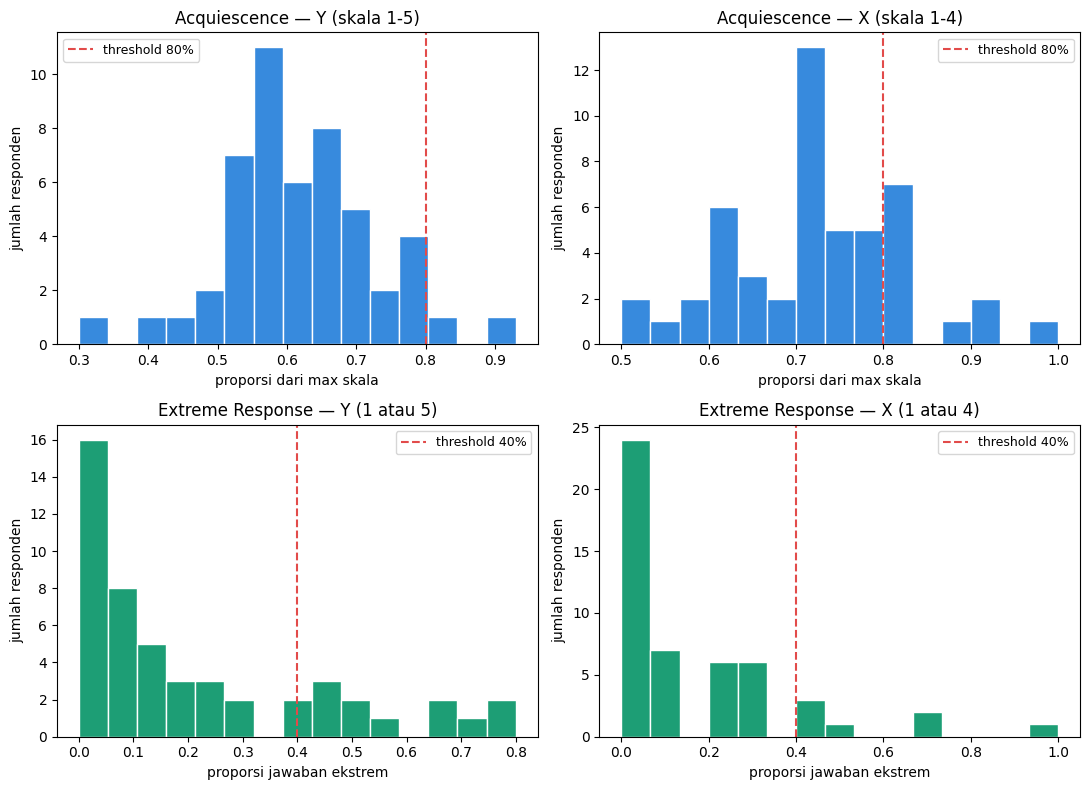

In [562]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# Acquiescence Y
axes[0,0].hist(y_mean, bins=15, color="#378ADD", edgecolor="white")
axes[0,0].axvline(0.8, color="#E24B4A", linestyle="--", linewidth=1.5, label="threshold 80%")
# axes[0,0].axvline(0.2, color="#E24B4A", linestyle="--", linewidth=1.5, label="threshold 20%")
axes[0,0].set_title("Acquiescence — Y (skala 1-5)")
axes[0,0].set_xlabel("proporsi dari max skala")
axes[0,0].set_ylabel("jumlah responden")
axes[0,0].legend(fontsize=9)

# Acquiescence X
axes[0,1].hist(x_mean, bins=15, color="#378ADD", edgecolor="white")
axes[0,1].axvline(0.8, color="#E24B4A", linestyle="--", linewidth=1.5, label="threshold 80%")
# axes[0,1].axvline(0.2, color="#E24B4A", linestyle="--", linewidth=1.5, label="threshold 20%")
axes[0,1].set_title("Acquiescence — X (skala 1-4)")
axes[0,1].set_xlabel("proporsi dari max skala")
axes[0,1].set_ylabel("jumlah responden")
axes[0,1].legend(fontsize=9)

# Extreme Y
axes[1,0].hist(extreme_y, bins=15, color="#1D9E75", edgecolor="white")
axes[1,0].axvline(0.4, color="#E24B4A", linestyle="--", linewidth=1.5, label="threshold 40%")
axes[1,0].set_title("Extreme Response — Y (1 atau 5)")
axes[1,0].set_xlabel("proporsi jawaban ekstrem")
axes[1,0].set_ylabel("jumlah responden")
axes[1,0].legend(fontsize=9)

# Extreme X
axes[1,1].hist(extreme_x, bins=15, color="#1D9E75", edgecolor="white")
axes[1,1].axvline(0.4, color="#E24B4A", linestyle="--", linewidth=1.5, label="threshold 40%")
axes[1,1].set_title("Extreme Response — X (1 atau 4)")
axes[1,1].set_xlabel("proporsi jawaban ekstrem")
axes[1,1].set_ylabel("jumlah responden")
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Filter Data dan Export Data

In [563]:
df_final = pd.concat([df.iloc[:, 1:3], df.iloc[:, 23:33]], axis = 1)

In [564]:
df_final[flagged].index

Index([5, 26, 32, 34, 37, 39, 43], dtype='int64')

In [565]:
df_final.shape

(50, 12)

In [566]:
var_y = var_y.drop(index=df_final[flagged].index)
var_x = var_x.drop(index=df_final[flagged].index)
df_final = df_final.drop(index=df_final[flagged].index)

In [567]:
print(df_final.shape)
df_final.head()

(43, 12)


,Kelas,Gender,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,LC09,Pria,3,3,2,2,3,3,2,3,2,2
1,LA09,Wanita,3,2,2,2,2,3,2,2,2,2
2,LB09,Pria,4,3,3,2,2,4,3,3,3,2
3,LB09,Pria,3,3,3,2,3,4,3,4,3,4
4,LB09,Wanita,3,3,2,2,3,3,3,3,3,3


In [568]:
df_final.to_csv('df.csv', index=False)
var_y.to_csv('var_y.csv', index=False)
var_x.to_csv('var_x.csv', index=False)